### APPLICATION TO NEW YORK TIMES. News Analysis Data Extraction
Now we apply our code for Japan to a different country and news outlet.
Using the same code and with minimal tweaks, we confirm the tool's replicability.
Extracts article data from csv file
This will probably turn into a .py file to extract data later but just playing around right now

In [42]:
import pandas as pd

nyt_filepath = "../../project/data/raw/US-Media_NYTimesIndex_16.1.csv"
nyt_pd = pd.read_csv(nyt_filepath) # set delimiter to tab
nyt_pd.head(10)

C:\Users\marti\AppData\Local\Temp\ipykernel_31596\1215163717.py:4: DtypeWarning: Columns (3,6,17,24,25) have mixed types. Specify dtype option on import or set low_memory=False.
  nyt_pd = pd.read_csv(nyt_filepath) # set delimiter to tab


,id,year,Source,PageNumber,BeginningWords,Date,Length,FrontPage,Description,majortopic,...,FederalAgency,President,CongressDum,Courts,StateLocalActors,CandidatesCampaigns,InterestGroups,Congress,Unnamed: 25,Unnamed: 26
0,1,1946,NYT Index 1946,1,Amalganated Bank of NY,12/10/46,9,0.0,Amalganated Bank of NY to finance art purchase,15.0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,79,NaN,NaN
1,2,1946,NYT Index 1946,3,Bail for Dr,11/24/46,9,0.0,Bail for Dr A. Flandina and V. Ryder halved ...,2.0,...,0,0.0,0.0,1.0,0.0,0.0,0.0,79,NaN,NaN
2,3,1946,NYT Index 1946,5,42 escape injury,10/19/46,9,0.0,42 escape injury when Pan amer Airway clipper ...,10.0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,79,NaN,NaN
3,4,1946,NYT Index 1946,7,"huffman, (Col)",4/23/46,9,0.0,"Huffman, HN and 19 others killed in crash(subj...",10.0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,79,NaN,NaN
4,5,1946,NYT Index 1946,9,Lifeguards J Grimmer,8/14/46,9,0.0,"Lifeguards J Grimmer, and F Garvin fined for d...",12.0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,79,NaN,NaN
5,6,1946,NYT Index 1946,11,3 escape injury,3/30/46,9,0.0,3 escape injury when auto stalls on tracks,10.0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,79,NaN,NaN
6,7,1946,NYT Index 1946,13,cartoon on speeding,1/20/46,9,0.0,cartoon on speeding9sujcet-accidents-motor veh...,10.0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,79,NaN,NaN
7,8,1946,NYT Index 1946,15,"37 hurt,",8/6/46,9,0.0,"37 hurt, bus plungees down embankment, chicago",10.0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,79,NaN,NaN
8,9,1946,NYT Index 1946,17,"Burns, (Justice)",11/16/46,9,0.0,"Burns, (Justice) F J, auto-collision, near Kin...",10.0,...,0,0.0,0.0,1.0,0.0,0.0,0.0,79,NaN,NaN
9,10,1946,NYT Index 1946,19,"Marcus, (miss)",4/30/46,9,0.0,"Marcus, (miss) J, LI RR train(subject: accidnt...",10.0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,79,NaN,NaN


In [43]:
nyt_pd.columns

Index(['id', 'year', 'Source', 'PageNumber', 'BeginningWords', 'Date',
       'Length', 'FrontPage', 'Description', 'majortopic', 'NYMetro',
       'Domestic', 'myNYC', 'myNYRegion', 'myDomestic', 'myUSinvolvement',
       'PublicPolicy', 'FederalAgency', 'President', 'CongressDum', 'Courts',
       'StateLocalActors', 'CandidatesCampaigns', 'InterestGroups', 'Congress',
       'Unnamed: 25', 'Unnamed: 26'],
      dtype='object')

In [44]:
# We correct a mistake in the dataset
nyt_pd.loc[nyt_pd["Date"] == "12/24/1015", "Date"] = "12/24/15"

# We rename some columns
nyt_pd = nyt_pd.rename(columns={
    "Description": "text",
    "Date": "date",
    "Source": "source"
})

nyt_pd.head(10)

,id,year,source,PageNumber,BeginningWords,date,Length,FrontPage,text,majortopic,...,FederalAgency,President,CongressDum,Courts,StateLocalActors,CandidatesCampaigns,InterestGroups,Congress,Unnamed: 25,Unnamed: 26
0,1,1946,NYT Index 1946,1,Amalganated Bank of NY,12/10/46,9,0.0,Amalganated Bank of NY to finance art purchase,15.0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,79,NaN,NaN
1,2,1946,NYT Index 1946,3,Bail for Dr,11/24/46,9,0.0,Bail for Dr A. Flandina and V. Ryder halved ...,2.0,...,0,0.0,0.0,1.0,0.0,0.0,0.0,79,NaN,NaN
2,3,1946,NYT Index 1946,5,42 escape injury,10/19/46,9,0.0,42 escape injury when Pan amer Airway clipper ...,10.0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,79,NaN,NaN
3,4,1946,NYT Index 1946,7,"huffman, (Col)",4/23/46,9,0.0,"Huffman, HN and 19 others killed in crash(subj...",10.0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,79,NaN,NaN
4,5,1946,NYT Index 1946,9,Lifeguards J Grimmer,8/14/46,9,0.0,"Lifeguards J Grimmer, and F Garvin fined for d...",12.0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,79,NaN,NaN
5,6,1946,NYT Index 1946,11,3 escape injury,3/30/46,9,0.0,3 escape injury when auto stalls on tracks,10.0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,79,NaN,NaN
6,7,1946,NYT Index 1946,13,cartoon on speeding,1/20/46,9,0.0,cartoon on speeding9sujcet-accidents-motor veh...,10.0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,79,NaN,NaN
7,8,1946,NYT Index 1946,15,"37 hurt,",8/6/46,9,0.0,"37 hurt, bus plungees down embankment, chicago",10.0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,79,NaN,NaN
8,9,1946,NYT Index 1946,17,"Burns, (Justice)",11/16/46,9,0.0,"Burns, (Justice) F J, auto-collision, near Kin...",10.0,...,0,0.0,0.0,1.0,0.0,0.0,0.0,79,NaN,NaN
9,10,1946,NYT Index 1946,19,"Marcus, (miss)",4/30/46,9,0.0,"Marcus, (miss) J, LI RR train(subject: accidnt...",10.0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,79,NaN,NaN


In [45]:
# We correct data format
month_day = nyt_pd["date"].str.split("/", expand=True)

month = month_day[0]
day = month_day[1]

nyt_pd["date"] = (
    nyt_pd["year"].astype(str)
    + "-"
    + month.str.zfill(2)
    + "-"
    + day.str.zfill(2)
)
nyt_pd[["year","date"]].head(10)

,year,date
0,1946,1946-12-10
1,1946,1946-11-24
2,1946,1946-10-19
3,1946,1946-04-23
4,1946,1946-08-14
5,1946,1946-03-30
6,1946,1946-01-20
7,1946,1946-08-06
8,1946,1946-11-16
9,1946,1946-04-30


In [46]:
# Convert to datatime
nyt_pd["date"] = pd.to_datetime(nyt_pd["date"])

#  Index by date
nyt_pd_indexed = nyt_pd.set_index("date")

In [47]:
# Sort by date
nyt_pd_indexed = nyt_pd_indexed.sort_index()
nyt_pd_indexed.head(10)


,id,year,source,PageNumber,BeginningWords,Length,FrontPage,text,majortopic,NYMetro,...,FederalAgency,President,CongressDum,Courts,StateLocalActors,CandidatesCampaigns,InterestGroups,Congress,Unnamed: 25,Unnamed: 26
date,,,,,,,,,,,,,,,,,,,,,
1946-01-01,306,1946,NYT Index 1946,611,J F Pietrafesa,9,0.0,NYC-Marshals: J F Pietrafesa apptd City Marshal.,24.0,1.0,...,0,0.0,0.0,0.0,1.0,0.0,0.0,79,NaN,NaN
1946-01-02,229,1946,NYT Index 1946,457,Shot to death in,9,0.0,Pasquale Cicarelli: shot to death in Berlin; 2...,16.0,3.0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,79,NaN,NaN
1946-01-02,118,1946,NYT Index 1946,235,death-sentence appeal,9,0.0,"Laszlo de Bardossy, death-sentence appeal denied;",12.0,3.0,...,0,0.0,0.0,1.0,0.0,0.0,0.0,79,NaN,NaN
1946-01-02,807,1946,NYT Index 1946,1613,takes oath as,9,0.0,"Noses, (Como) Robert takes oath as Park Comr a...",24.0,1.0,...,0,0.0,0.0,0.0,1.0,0.0,0.0,79,NaN,NaN
1946-01-02,180,1946,NYT Index 1946,359,returns to Iran,9,0.0,Smb sir Raeder W Bullard returns to Iran; conf...,19.0,3.0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,79,NaN,NaN
1946-01-03,113,1946,NYT Index 1946,225,USSR desires for,9,0.0,US Govt foreign loans policy: USSR desire for ...,18.0,3.0,...,1,0.0,0.0,0.0,0.0,0.0,0.0,79,NaN,NaN
1946-01-03,559,1946,NYT Index 1946,1117,US MIL Comm,9,0.0,War Crime Trial: US Mil Comm denies dismissal ...,16.0,3.0,...,1,0.0,0.0,0.0,0.0,0.0,0.0,79,NaN,NaN
1946-01-03,843,1946,NYT Index 1946,1685,F C Bals sworn,9,0.0,NYC Police Department: F C Bals sworn in as de...,24.0,1.0,...,0,0.0,0.0,0.0,1.0,0.0,0.0,79,NaN,NaN
1946-01-03,816,1946,NYT Index 1946,1631,S Gunn charged with,9,0.0,NYC: S Gunn charged with pushing man in front ...,12.0,1.0,...,0,0.0,0.0,0.0,1.0,0.0,0.0,79,NaN,NaN


In [48]:
# We check dates are correct
print(nyt_pd_indexed.index.min())
print(nyt_pd_indexed.index.max())

1946-01-01 00:00:00
2016-12-30 00:00:00


In [49]:
# Drop na values in Description
nyt_pd_indexed.dropna(subset=['text'], inplace=True)

nyt_pd_indexed = nyt_pd_indexed[["source","text"]]
nyt_pd_indexed.head(10)

,source,text
date,,
1946-01-01,NYT Index 1946,NYC-Marshals: J F Pietrafesa apptd City Marshal.
1946-01-02,NYT Index 1946,Pasquale Cicarelli: shot to death in Berlin; 2...
1946-01-02,NYT Index 1946,"Laszlo de Bardossy, death-sentence appeal denied;"
1946-01-02,NYT Index 1946,"Noses, (Como) Robert takes oath as Park Comr a..."
1946-01-02,NYT Index 1946,Smb sir Raeder W Bullard returns to Iran; conf...
1946-01-03,NYT Index 1946,US Govt foreign loans policy: USSR desire for ...
1946-01-03,NYT Index 1946,War Crime Trial: US Mil Comm denies dismissal ...
1946-01-03,NYT Index 1946,NYC Police Department: F C Bals sworn in as de...
1946-01-03,NYT Index 1946,NYC: S Gunn charged with pushing man in front ...


In [50]:
# Count number of total articles
indexed_numrows = len(nyt_pd_indexed)
indexed_numrows

56909

In [51]:
# Use indexed and sorted data to search for articles that contain the keyword "deflation" in them
nyt_pd_keyword_deflation = nyt_pd_indexed[nyt_pd_indexed['text'].str.contains('deflation', case=False)]
nyt_pd_keyword_deflation.head(10)

,source,text
date,,
1950-01-19,NYT Index 1950,article holds certain Fed deficit spending ten...
1971-05-25,NYT Index 1971,lr holds it is doubtful that revaluation of so...
1998-11-05,NYT Index 1998,Column says there is little evidence to sugges...
2001-01-27,NYT Index 2001,Government statistics show that Japan is in gr...
2014-10-25,NYT Index 2014,Coloumn discusses deflation in European countr...


In [52]:
# Count number of articles that contain keyword (compared to the total 12724)
keyword_numrows = len(nyt_pd_keyword_deflation)
keyword_numrows

5

In [53]:
# We try another keyword
nyt_pd_keyword_inflation = nyt_pd_indexed[nyt_pd_indexed['text'].str.contains('inflation', case=False)]
nyt_pd_keyword_inflation.head(10)

,source,text
date,,
1946-11-03,NYT Index 1946,France-Economic Conditions: Pres Bladault's wa...
1946-11-20,NYT Index 1946,"Coal--US: ed, One-Man inflation"
1947-09-28,NYT Index 1947,Eastern subcom aims and data from hearings rev...
1947-12-21,NYT Index 1947,letter on inflation control
1952-02-10,NYT Index 1952,Prof sees new wage rises bringing price rises ...
1953-01-22,NYT Index 1953,A Sproul urges productivity as inflation bar
1953-09-20,NYT Index 1953,Sen Dirksen charges Truman Adm kept agri. pric...
1956-06-10,NYT Index 1956,MP Bevan of Great Britain ascribes inflation ...
1956-09-12,NYT Index 1956,Assn charges Adm 'money mgrs' restrict mortgag...


In [54]:
len(nyt_pd_keyword_inflation)

153

## Count Function

Define a function to get article count containing keyword - start of migrating to .py files

Use python file keywords.py

In [55]:
import sys
sys.path.append("../src")

import importlib
import keywords

importlib.reload(keywords)
from keywords import CATEGORY_KEYWORDS

In [56]:
from keywords import CATEGORY_KEYWORDS          # ← ADD: import the shared dictionary

def keyword_article_count(keyword, df):
    return df['text'].str.contains(keyword, case=False, na=False).sum()

rows = []
for category, keywords in CATEGORY_KEYWORDS.items():   # ← CHANGE: categories → CATEGORY_KEYWORDS
    for kw in keywords:
        count = keyword_article_count(kw, nyt_pd_indexed)
        rows.append({"category": category, "keyword": kw, "article_count": count})

results_df = pd.DataFrame(rows).sort_values(["category", "article_count"], ascending=[True, False])
results_df


,category,keyword,article_count
1,defense,china,524
6,defense,defense,479
10,defense,military,371
5,defense,threat,364
17,defense,russia,316
...,...,...,...
55,nuclear,nuclear disarmament,3
52,nuclear,fukushima,2
47,nuclear,atomic bomb survivors,0
56,nuclear,non-proliferation,0


In [57]:
results_df.head(10)

,category,keyword,article_count
1,defense,china,524
6,defense,defense,479
10,defense,military,371
5,defense,threat,364
17,defense,russia,316
18,defense,army,303
16,defense,troops,226
11,defense,navy,119
8,defense,missile,111
12,defense,security council,94


In [58]:
len(nyt_pd_indexed)

56909

In [59]:
def category_article_count(keywords, df):
    pattern = "|".join(keywords)
    return df['text'].str.contains(pattern, case=False, na=False).sum()

rows = []
for category, keywords in CATEGORY_KEYWORDS.items():   # ← CHANGE: categories → CATEGORY_KEYWORDS
    count = category_article_count(keywords, nyt_pd_indexed)
    rows.append({"category": category, "unique_articles": count})

category_totals = pd.DataFrame(rows).sort_values("unique_articles", ascending=False)
category_totals

,category,unique_articles
1,economy,7868
0,defense,2823
2,nuclear,609
3,immigration,609


Normalisation of article count  


In [60]:
yearly_count = nyt_pd_indexed.groupby(nyt_pd_indexed.index.year).size()
print(yearly_count)

date
1946.0     878
1947.0    1204
1948.0     603
1949.0     580
1950.0     628
          ... 
2012.0    1028
2013.0     970
2014.0    1081
2015.0    1272
2016.0    1070
Length: 71, dtype: int64


In [61]:

nyt_pd_indexed['year'] = nyt_pd_indexed.index.year

def category_article_count_by_year(keywords, df):
    pattern = "|".join(keywords)
    mask = df['text'].str.contains(pattern, case=False, na=False)
    return df[mask].groupby('year').size()

# Total articles per year (denominator)
total_per_year = nyt_pd_indexed.groupby('year').size()

# Count matching articles per category per year, then normalise
rows = []
for category, keywords in CATEGORY_KEYWORDS.items():
    counts_by_year = category_article_count_by_year(keywords, nyt_pd_indexed)
    normalised = (counts_by_year / total_per_year).fillna(0)
    
    for year, norm_value in normalised.items():
        rows.append({
            "category": category,
            "year": year,
            "article_count": counts_by_year.get(year, 0),
            "total_articles": total_per_year[year],
            "normalised_share": norm_value
        })

category_normalised = pd.DataFrame(rows).sort_values(["category", "year"])
category_normalised.head(50)

,category,year,article_count,total_articles,normalised_share
0,defense,1946.0,43,878,0.048975
1,defense,1947.0,55,1204,0.045681
2,defense,1948.0,20,603,0.033167
3,defense,1949.0,28,580,0.048276
4,defense,1950.0,34,628,0.054140
5,defense,1951.0,61,605,0.100826
6,defense,1952.0,32,643,0.049767
7,defense,1953.0,19,603,0.031509
8,defense,1954.0,38,608,0.062500
9,defense,1955.0,26,631,0.041204


## Graph Function

Define a function to graph article with keyword occurences over time

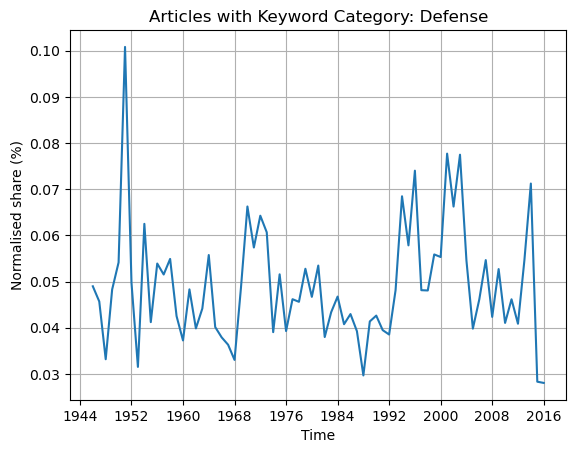

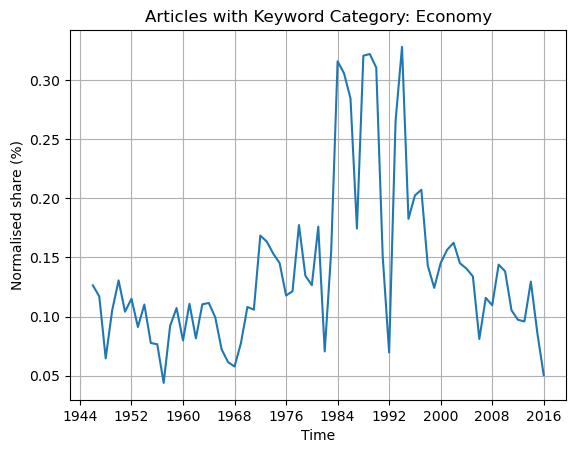

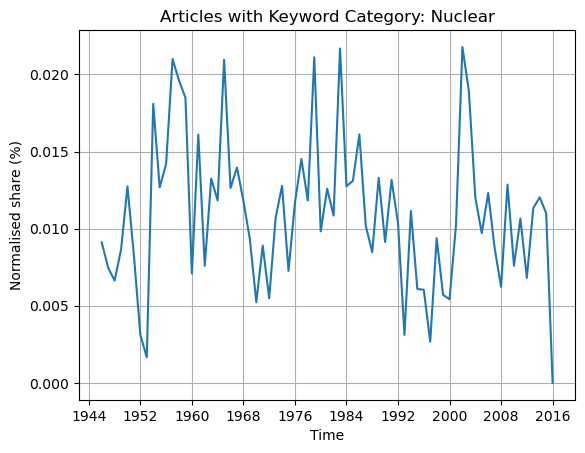

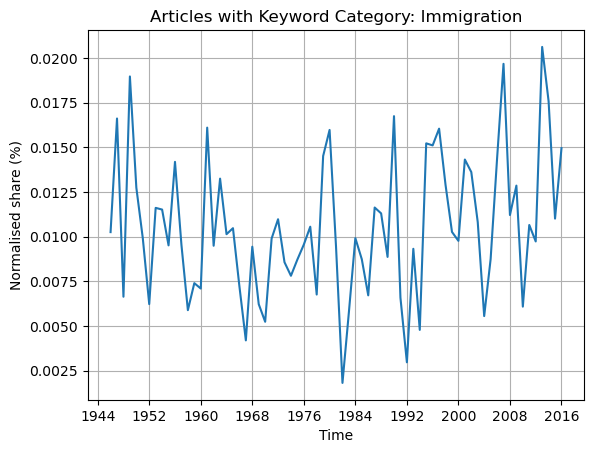

In [62]:
import matplotlib.pyplot as plt

def category_graph(category_name, category_normalised, x_title, y_title, main_title):

    df_plot = category_normalised[category_normalised['category'] == category_name]

    fig, ax = plt.subplots()
    ax.plot(df_plot['year'].astype(int), df_plot['normalised_share'])
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax.set_xlabel(x_title)
    ax.set_ylabel(y_title)
    ax.set_title(main_title)
    ax.grid(True)
    
    return fig

# Save the figure
for category in CATEGORY_KEYWORDS.keys():
 fig = category_graph(
        category_name=category,
        category_normalised=category_normalised,       
        x_title="Time",
        y_title="Normalised share (%)",
        main_title=f"Articles with Keyword Category: {category.capitalize()}"
    )
 fig.savefig(f"{category}_NYT_articles_plot.png", bbox_inches='tight', dpi=300)
 plt.show()

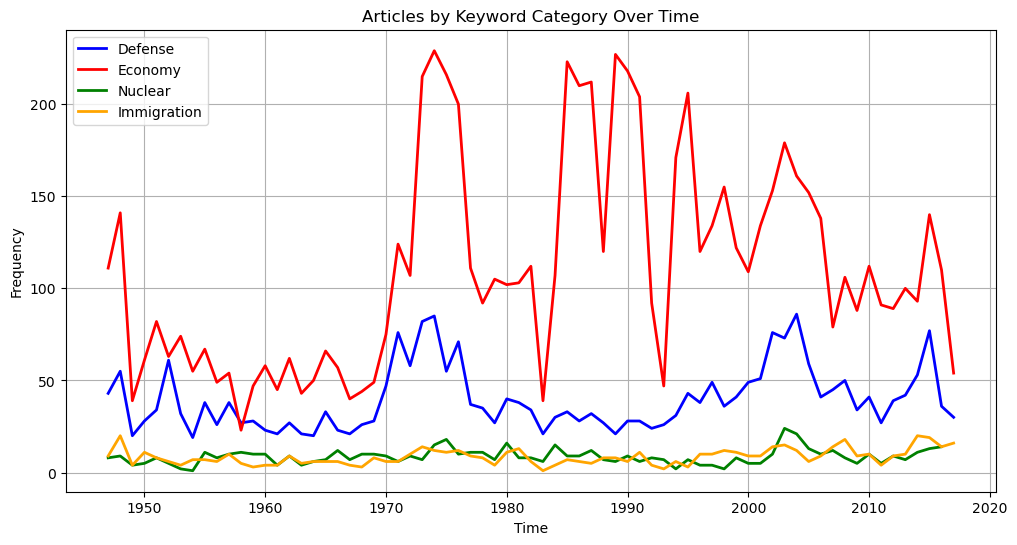

In [66]:
import matplotlib.pyplot as plt

COLORS = ['blue', 'red', 'green', 'orange']

fig, ax = plt.subplots(figsize=(12, 6))

for (category, keywords), color in zip(CATEGORY_KEYWORDS.items(), COLORS):
    pattern = "|".join(keywords)
    nyt_pd_keyword = nyt_pd_indexed[nyt_pd_indexed['text'].str.contains(pattern, case=False, na=False)]
    df_plot = nyt_pd_keyword.resample('YE').size()
    ax.plot(df_plot.index, df_plot.values, label=category.capitalize(), color=color, linewidth=2)

ax.set_xlabel("Time")
ax.set_ylabel("Frequency")
ax.set_title("Articles by Keyword Category Over Time")
ax.legend(loc='upper left')
ax.grid(True)

fig.savefig("NYT_combined_categories_plot.png", bbox_inches='tight', dpi=300)
plt.show()

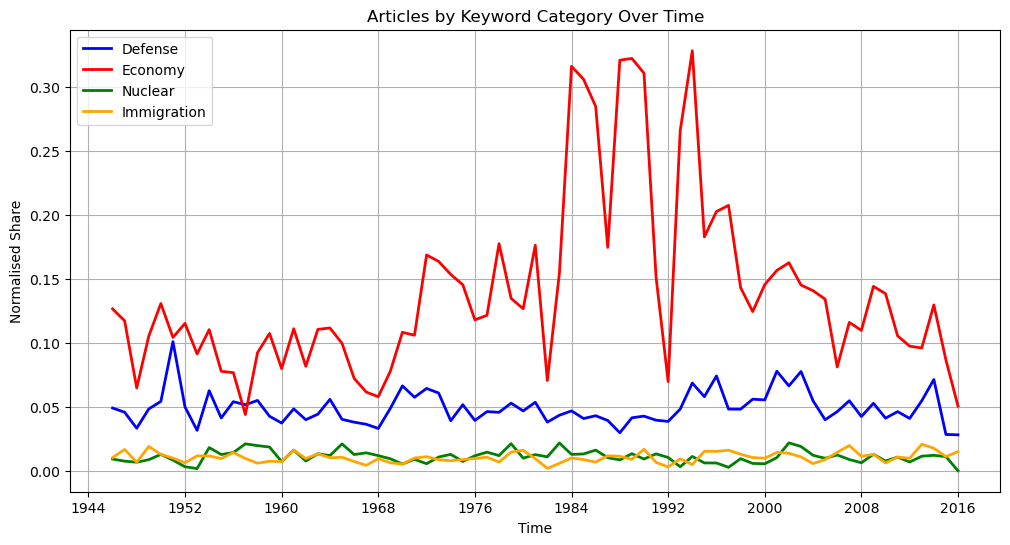

In [ ]:
import matplotlib.pyplot as plt

COLORS = ['blue', 'red', 'green', 'orange']

fig, ax = plt.subplots(figsize=(12, 6))

for category, color in zip(CATEGORY_KEYWORDS.keys(), COLORS):  # ← CHANGE: removed `keywords` from loop
    df_plot = category_normalised[category_normalised['category'] == category]  # ← CHANGE: replaced pattern matching + resample with filter
    ax.plot(df_plot['year'].astype(int), df_plot['normalised_share'], label=category.capitalize(), color=color, linewidth=2)  # ← CHANGE: replaced df_plot.index, df_plot.values with year and normalised_share; added astype(int)

ax.set_xlabel("Time")
ax.set_ylabel("Normalised Share")  # ← CHANGE: updated y-axis label
ax.set_title("Articles by Keyword Category Over Time")
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))  # ← ADD: force integer x-axis ticks
ax.legend(loc='upper left')
ax.grid(True)

fig.savefig("NYT_combined_categories_plot.png", bbox_inches='tight', dpi=300)
plt.show()

### Regression analysis 
We use the database on US speeches to build our regression analysis

In [69]:
speeches_normalised = pd.read_csv('../data/clean/us_speeches_normalised.csv')
merged_df = pd.merge(speeches_normalised, category_normalised, on=['category', 'year'], suffixes=('_speeches', '_articles'))
merged_df

,category,year,keyword_speeches,total_speeches,normalised_share_speeches,article_count,total_articles,normalised_share_articles
0,defense,2004,14,282,0.049645,59,1081,0.054579
1,defense,2005,9,239,0.037657,41,1030,0.039806
2,defense,2006,11,287,0.038328,45,975,0.046154
3,defense,2007,15,288,0.052083,50,915,0.054645
4,defense,2008,18,314,0.057325,34,803,0.042341
5,defense,2009,4,304,0.013158,41,778,0.052699
6,defense,2010,11,424,0.025943,27,658,0.041033
7,defense,2011,18,398,0.045226,39,845,0.046154
8,defense,2012,19,418,0.045455,42,1028,0.040856
9,defense,2013,19,370,0.051351,53,970,0.054639


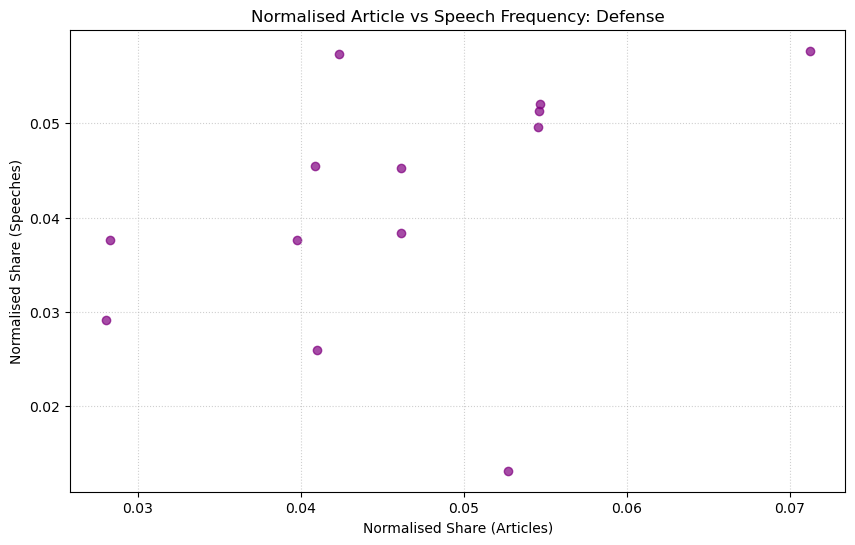

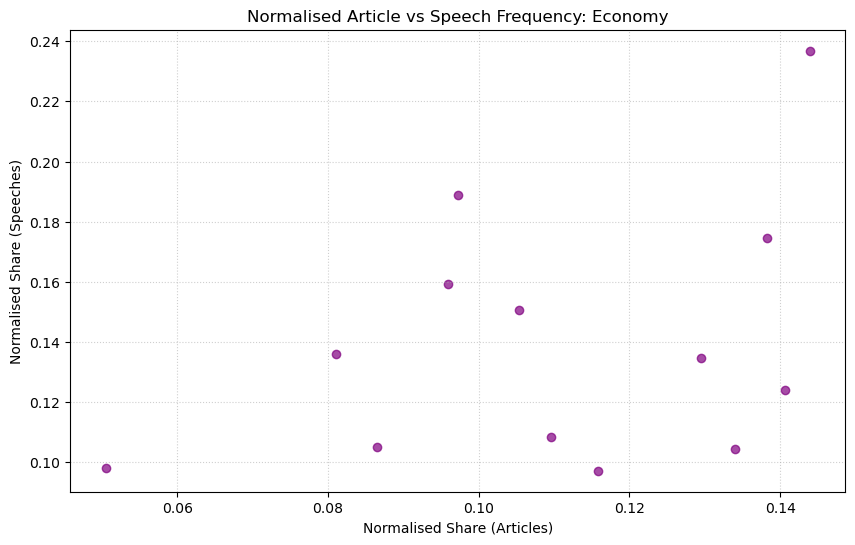

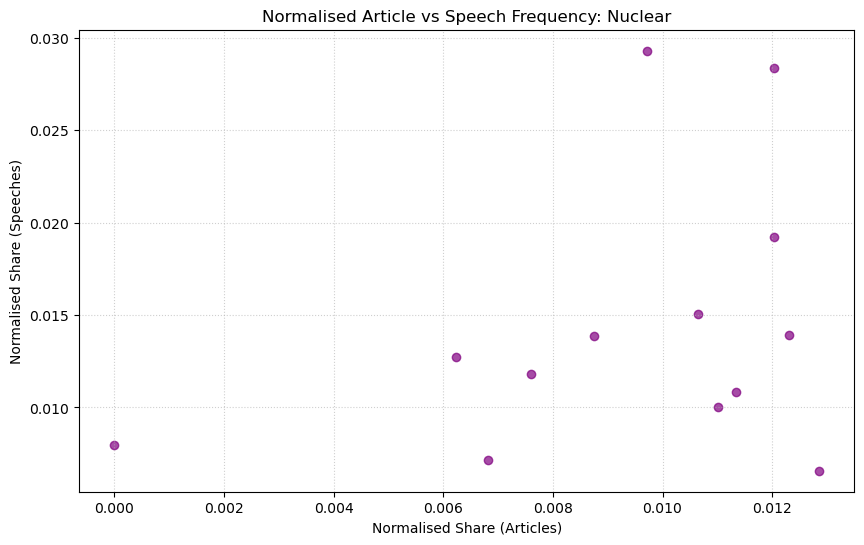

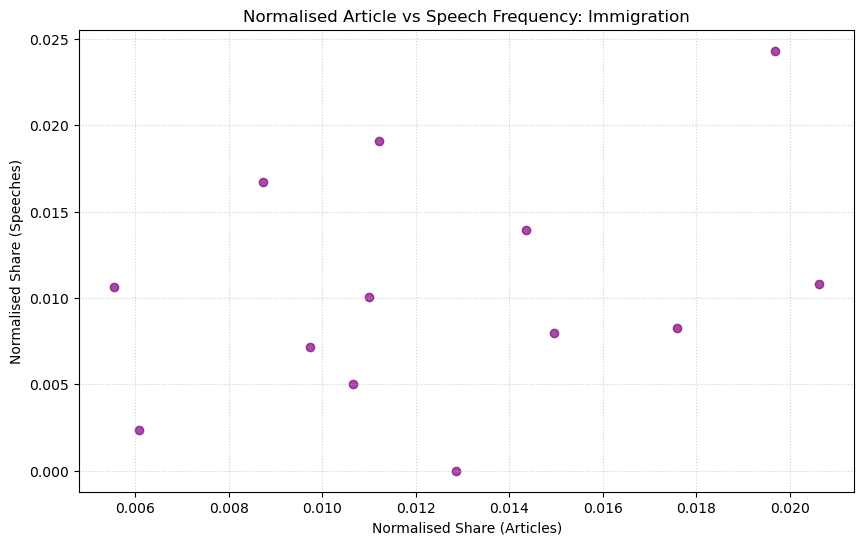

In [70]:
for category in CATEGORY_KEYWORDS.keys():
    df_plot = merged_df[merged_df['category'] == category]

    plt.figure(figsize=(10, 6))
    plt.scatter(x=df_plot['normalised_share_articles'], y=df_plot['normalised_share_speeches'], color='purple', alpha=0.7)

    plt.title(f"Normalised Article vs Speech Frequency: {category.capitalize()}")
    plt.xlabel("Normalised Share (Articles)")
    plt.ylabel("Normalised Share (Speeches)")
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.show()

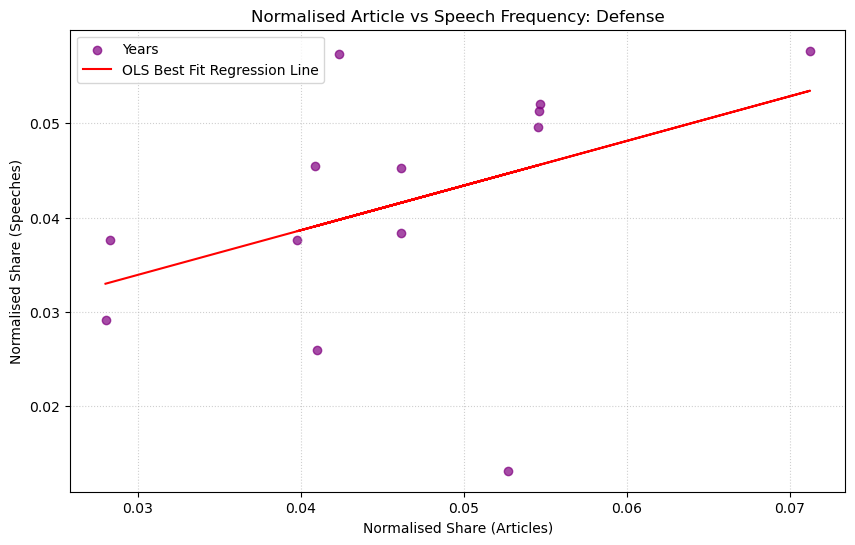

Defense: R²=0.179, p-value=0.149


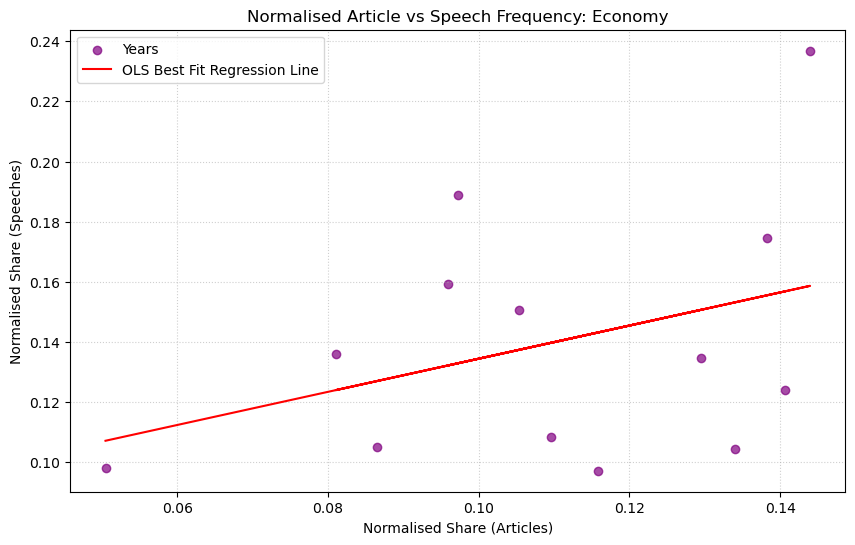

Economy: R²=0.134, p-value=0.218


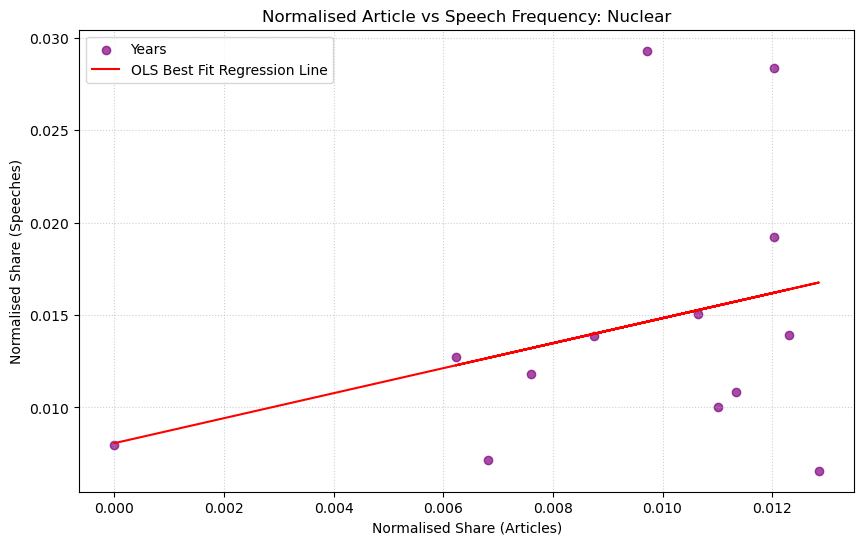

Nuclear: R²=0.108, p-value=0.273


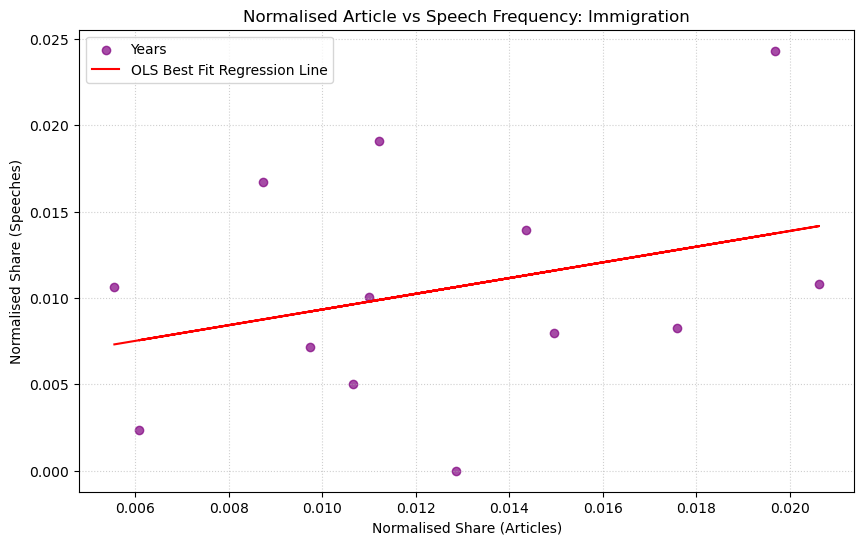

Immigration: R²=0.103, p-value=0.285


In [71]:
import statsmodels.api as sm

for category in CATEGORY_KEYWORDS.keys():
    df_plot = merged_df[merged_df['category'] == category].dropna()

    X = sm.add_constant(df_plot['normalised_share_articles'])
    y = df_plot['normalised_share_speeches']
    model = sm.OLS(y, X).fit()

    intercept, slope = model.params.iloc[0], model.params.iloc[1]

    plt.figure(figsize=(10, 6))
    plt.scatter(df_plot['normalised_share_articles'], df_plot['normalised_share_speeches'], color='purple', alpha=0.7, label='Years')
    plt.plot(df_plot['normalised_share_articles'], intercept + slope * df_plot['normalised_share_articles'], color='red', label='OLS Best Fit Regression Line')

    plt.title(f"Normalised Article vs Speech Frequency: {category.capitalize()}")
    plt.xlabel("Normalised Share (Articles)")
    plt.ylabel("Normalised Share (Speeches)")
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.show()

    print(f"{category.capitalize()}: R²={model.rsquared:.3f}, p-value={model.pvalues.iloc[1]:.3f}")

## Word cloud
We re-use our tool to build a word cloud for NYT articles

In [ ]:
# 1.1.
%pip install wordcloud
import os
import re
import sys
from collections import Counter, defaultdict
import pandas as pd
import matplotlib.pyplot as plt
import spacy
from wordcloud import WordCloud
_CATEGORY_KEYWORDS = globals().get("CATEGORY_KEYWORDS")
sys.path.append("notebooks")
try:
	from keywords import CATEGORY_KEYWORDS as _CATEGORY_KEYWORDS
except Exception:
	_CATEGORY_KEYWORDS = {}
# expose as CATEGORY_KEYWORDS for the rest of the notebook
CATEGORY_KEYWORDS = _CATEGORY_KEYWORDS

# 1.2._Aillie's engine
YEAR_START, YEAR_END = 1946, 2015
TARGET_POS = {"NOUN", "PROPN", "ADJ"}
GLUE_WORDS = {"of", "the", "this", "these", "those", "our", "their", "his", "her", "on"}
GENERIC_NOUNS = {
    "number", "amount", "kind", "type", "part", "lot", "rest", "use",
    "case", "way", "fact", "thing", "point", "matter", "issue", "term",
}
MIN_DOC_FREQ = 2
nlp = spacy.load("en_core_web_sm")
ALL_POLITICAL_KEYWORDS = set().union(*CATEGORY_KEYWORDS.values())

# 2. Load and filter NYT data
df_us_range = nyt_pd_indexed[
    (nyt_pd_indexed["year"] >= YEAR_START) &
    (nyt_pd_indexed["year"] <= YEAR_END)
].copy()

def extract_phrases(text):
    doc = nlp(str(text))
    tokens = [t for t in doc if not t.is_space and not t.is_punct]
    phrases = []
    i = 0
    while i < len(tokens):
        phrase_tokens = []
        j = i
        while j < len(tokens) and (
            tokens[j].pos_ in TARGET_POS
            or (tokens[j].text.lower() in GLUE_WORDS and phrase_tokens)
        ):
            phrase_tokens.append(tokens[j].text)
            j += 1

        while phrase_tokens and phrase_tokens[-1].lower() in GLUE_WORDS:
            phrase_tokens.pop()
            j -= 1

        if (
            len(phrase_tokens) >= 2
            and phrase_tokens[0].lower() not in GENERIC_NOUNS
            and phrase_tokens[-1].lower() not in GENERIC_NOUNS
        ):
            phrases.append(" ".join(phrase_tokens).lower())

        i = j if j > i else i + 1
    return phrases

def is_political(phrase):
    return any(keyword in phrase for keyword in ALL_POLITICAL_KEYWORDS)
phrase_counts = Counter()
phrase_doc_ids = defaultdict(set)

print("Extracting multi-word political phrases...")
for idx, row in df_us_range.iterrows():
    for phrase in extract_phrases(row["text"]):
        if not is_political(phrase):
            continue
        phrase_counts[phrase] += 1
        phrase_doc_ids[phrase].add(idx)

# 5. Build the dictionary strictly from the extracted phrases
final_frequencies = {
    phrase: count for phrase, count in phrase_counts.items()
    if len(phrase_doc_ids[phrase]) >= MIN_DOC_FREQ
}

# 6. Generate the word cloud using the actual phrase frequencies
if not final_frequencies:
	if "top_political_phrases_df" in globals() and not top_political_phrases_df.empty:
		final_frequencies = top_political_phrases_df.set_index("phrase")["total_count"].to_dict()
	elif "phrase_frequencies" in globals() and phrase_frequencies:
		final_frequencies = phrase_frequencies
	else:
		raise ValueError(
			"No phrase frequencies available for the word cloud. "
			"Check CATEGORY_KEYWORDS import and phrase extraction."
		)

political_wordcloud = WordCloud(
	width=1000,
	height=600,
	background_color="white",
	collocations=False
).generate_from_frequencies(final_frequencies)

# 7. Plot and save
plt.figure(figsize=(12, 7))
plt.imshow(political_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title(f"Political Key-Phrases in NYT articles ({YEAR_START}-{YEAR_END})")

wordcloud_fig_path = os.path.join(
    "..",
    "reports",
    "figures",
    "nyt_phrases_wordcloud.png"
)
plt.savefig(wordcloud_fig_path, bbox_inches='tight')
plt.show()

Note: you may need to restart the kernel to use updated packages.
Extracting multi-word political phrases...


## Notes
